In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.7/644.7 kB 8.5 MB/s eta 0:00:00


In [2]:
import os
import pickle
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
import tensorflow as tf
import cv2
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Resizing,Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, BatchNormalization, Dropout, Dense
from tensorflow.keras.preprocessing.image import img_to_array, smart_resize
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications import VGG16, MobileNet
from PIL import Image
import base64
from ultralytics import YOLO

In [3]:
def get_features(model, image):
    image = cv2.resize(image, (224,224))
    image = np.expand_dims(image, axis=0)
    features = model.predict(image, verbose=False)
    return features.flatten().reshape(1,-1)

In [4]:
model1 = "/content/drive/MyDrive/Kartik /Prawns(STACKED_MODEL)/ML_MODELS/Decision Tree_VGG16_model(good).pkl"
model2 = "/content/drive/MyDrive/Kartik /Prawns(STACKED_MODEL)/ML_MODELS/Logistic Regression_VGG16_model(bad).pkl"
model3 = "/content/drive/MyDrive/Kartik /Prawns(STACKED_MODEL)/ML_MODELS/Logistic Regression_MobileNet_model(balanced).pkl"
vgg = VGG16(weights='imagenet', include_top=False)
vgg.trainable = False
mobilenet = MobileNet(weights='imagenet', include_top=False)
mobilenet.trainable=False
import joblib
model1 = joblib.load(model1)
model2 = joblib.load(model2)
model3 = joblib.load(model3)

yolo = YOLO(r'/content/drive/MyDrive/Kartik /Prawns(STACKED_MODEL)/prawn.pt')

58889256/58889256 [==============================] - 2s 0us/step


17225924/17225924 [==============================] - 1s 0us/step


In [5]:
def prediction(image):
  labels = ['Bad', 'Good']
  vgg_features = get_features(vgg, image)
  pred1 = model1.predict(vgg_features)
  pred2 = model2.predict(vgg_features)
  if pred1 == pred2:
    return labels[pred1[0]]
  else:
    mobilenet_features = get_features(mobilenet, image)
    pred3 = model3.predict(mobilenet_features)
    return labels[pred3[0]]

In [6]:
def extract_single_image_segment(img, mask_segment, shape):
    height, width = shape[0], shape[1]
    segment = np.array(mask_segment, dtype=np.int32)
    segment = segment.reshape((-1, 2))
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(mask, [segment], 255)
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    x, y, w, h = cv2.boundingRect(segment)
    segment_image = np.zeros((h, w, 3), dtype=np.uint8)
    segment_image[0:h, 0:w] = masked_img[y:y+h, x:x+w]
    black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
    segment_image[black_mask] = [255, 255, 255]
    return segment_image

def process_image(image, size=(1280, 1280)):
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)

    resized_image = cv2.resize(image, (new_w, new_h))

    pad_h = (size[1] - new_h) // 2
    pad_w = (size[0] - new_w) // 2
    padded_image = cv2.copyMakeBorder(
        resized_image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    padded_image = cv2.resize(padded_image, (1280, 1280))
    return np.asarray(padded_image)

In [7]:
def final_prediction2(image,raw=False):
  image = cv2.imread(image)
  image = np.asarray(image)
  shape = image.shape
  try:
     pred = yolo.predict(image, conf=0.75, verbose=False)
  except:
     return None
  if len(pred[0].boxes.xyxy) == 0 or pred[0].masks == None:
     return None
  boxes = pred[0].boxes.xyxy
  masks=pred[0].masks.xy
  filtered_boxes = sorted(boxes, key=lambda bbox: bbox[0])
  sorted_masks = [masks[i] for i in sorted(range(len(masks)), key=lambda x: boxes[x][0])]
  freshness = []
  for mask in sorted_masks:
    extracted_image = extract_single_image_segment(image, mask, shape)
    extracted_image = process_image(extracted_image)
    freshness.append(prediction(extracted_image))
  return freshness

In [8]:
final_prediction2('/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data/Mackerel/Bad/20230520105846433_mackerel_bad.jpeg',raw=False)

['Good']

In [9]:
from glob import glob
from tqdm import tqdm
bad_images = glob('/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data/White prawns/Bad/*.jpeg')
good_images = glob('/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data/White prawns/Good/*.jpeg')

len(bad_images),len(good_images)

(3099, 2681)

In [10]:
results= {}
actual = {}

actual_labels = []
predicted_labels = []
for img in tqdm(bad_images[::2]):
  try:
    lst = final_prediction2(img)
    if lst == None:
      continue
    actual_labels += ['Bad'] * len(lst)
    predicted_labels+=lst
    good = lst.count('Good')
    bad = lst.count('Bad')
    actual['Bad'] = results.get('Bad', 0) + bad + good
    results['Good'] = results.get('Good', 0) + good
    results['Bad'] = results.get('Bad', 0) + bad
  except:
    continue


for img in tqdm(good_images[::2]):
  if len(actual_labels) >= len(bad_images) * 2:
    break
  try:
    lst = final_prediction2(img)
    if lst == None:
      continue
    actual_labels += ['Good'] * len(lst)
    predicted_labels+=lst
    good = lst.count('Good')
    bad = lst.count('Bad')
    actual['Good'] = results.get('Good', 0) + bad + good
    results['Good'] = results.get('Good', 0) + good
    results['Bad'] = results.get('Bad', 0) + bad
  except:
    continue

100%|██████████| 1341/1341 [31:34<00:00,  1.41s/it]


Overall Accuracy: 57.28%


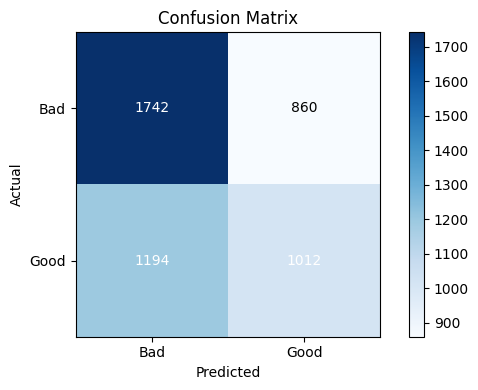

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(actual_labels, predicted_labels, labels=['Bad', 'Good'])
plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(['Bad', 'Good']))
plt.xticks(tick_marks, ['Bad', 'Good'], rotation=0)
plt.yticks(tick_marks, ['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(len(['Bad', 'Good'])):
    for j in range(len(['Bad', 'Good'])):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
accuracy = accuracy_score(actual_labels, predicted_labels)
print(f"Overall Accuracy: {accuracy:.2%}")
plt.show()